# Sheet 5

In [ ]:
import os
import pandas as pd

## 2 Logistic regression: an LLM lie detector

Download the data from https://heibox.uni-heidelberg.de/f/38bd3f2a9b7944248cc2/   
Unzip it and place the lie_detection folder in the folder named `data` to get the following structure:
"data/lie_detection/datasets" and "data/lie_detection/acts".

This is how you can load a dataset of LLM activations. Use a new Datamanager if you want to have a new dataset. Use the same data manager if you want to combine datasets.

In [ ]:
from lie_detection_utils import DataManager

path_to_datasets = "data/lie_detection/datasets"
path_to_acts = "data/lie_detection/acts"

# check if the datasets and activations are available
assert os.path.exists(path_to_datasets), "The path to the datasets does not exist."
assert os.path.exists(path_to_acts), "The path to the activations does not exist."

# these are the different datasets containing true and false factual statements about different topics
dataset_names = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans"]
dataset_name = dataset_names[0] # choose some dataset from the above datasets, index "0" loads the "cities" dataset for example

# the dataloader automatically loads the training data for us
dm = DataManager()
dm.add_dataset(dataset_name, "Llama3", "8B", "chat", layer=12, split=0.8, center=False,
                device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
acts_train, labels_train = dm.get('train') # train set
acts_test, labels_test = dm.get('val')
print(acts_train.shape, labels_train.shape)

In [ ]:
# have a look at the statements that were fed to the LLM to produce the activations:
df = pd.read_csv(f"{path_to_datasets}/{dataset_name}.csv")
print(df.head(10))

## 3 Log-sum-exp and soft(arg)max
### (b)

### (c)

## 4 Linear regions of MLPs

Part (a)

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class ShallowModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)  # Initialize the base neural network class

        # Hidden layer takes 2 inputs and sends to 20 neurons
        self.hidden_layer = nn.Linear(2, 20)  # Parameters: 2 inputs * 20 neurons + 20 biases = 40 weights + 20 biases = 60 parameters total

        # Output layer takes 20 inputs and sends to 1 output neuron
        self.output_layer = nn.Linear(20, 1)  # Parameters: 20 inputs * 1 output + 1 bias = 20 weights + 1 bias = 21 parameters total

    def forward(self, x):
        # Pass the input through the hidden layer and apply ReLU to keep only positive values
        x = torch.relu(self.hidden_layer(x))

        # Pass the result through the output layer to get the final value
        x = self.output_layer(x)

        return x

shallow_model = ShallowModel()
num_params = 0
for param in shallow_model.parameters():
    # If the parameter can be learned (i.e., updated during training)
    if param.requires_grad:

        num_params += param.numel()
print("The number of parameters in the model is:", num_params)  # Output: The number of parameters in the model is: 81


The number of parameters in the model is: 81


Part (b)

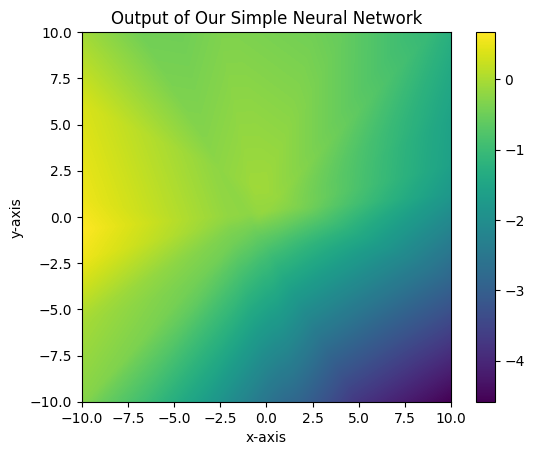

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# Define the range of values for x and y, from -10 to 10 with 500 points each
x_values = np.linspace(-10, 10, 500)
y_values = np.linspace(-10, 10, 500)


xx = []  # List to hold all x coordinates of the grid
yy = []  # List to hold all y coordinates of the grid
for y in y_values:
    for x in x_values:
        xx.append(x)
        yy.append(y)


grid_points = []
for i in range(len(xx)):
    grid_points.append([xx[i], yy[i]])

grid_points = np.array(grid_points)  # Shape  (250000, 2)

grid_tensor = torch.tensor(grid_points, dtype=torch.float32)  # Convert to a tensor for PyTorch

# We do not need to calculate gradients, hence the no_grad context manager
with torch.no_grad():
    output_tensor = shallow_model(grid_tensor)  # Pass the grid through the shallow model
    output_values = output_tensor.numpy()  # Convert the output tensor to NumPy array

output_values = output_values.reshape((500, 500))  # Reshape to match the grid of x and y  (500 x 500)

plt.imshow(output_values, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()  # Add color bar to show the value range
plt.title("Output of Our Simple Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()  # Display the plot


Part (C)

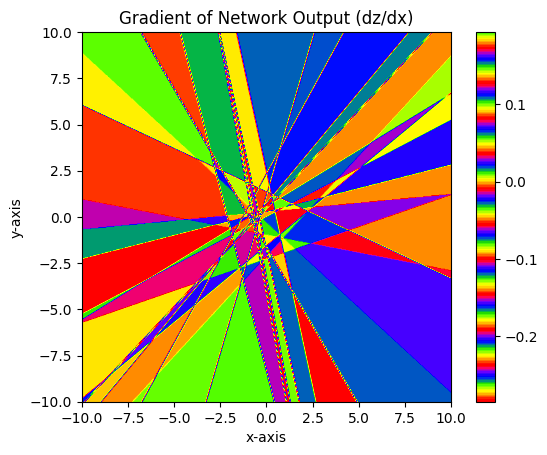

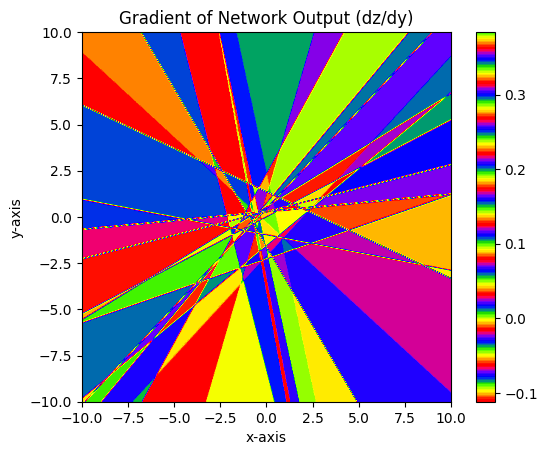

In [13]:
import numpy as np
import matplotlib.pyplot as plt


gradient_y, gradient_x = np.gradient(output_values, y_values, x_values)

plt.imshow(gradient_x, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

plt.imshow(gradient_y, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


Part (d)

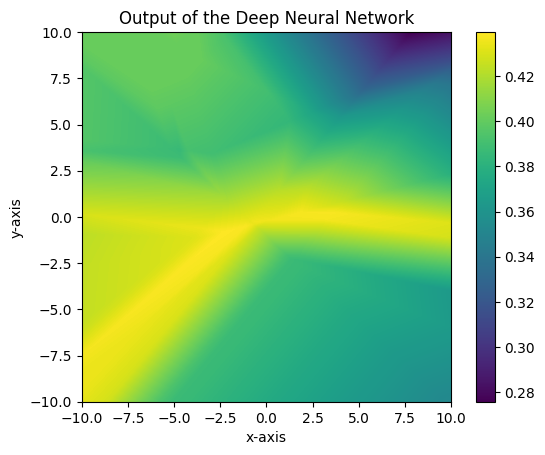

In [17]:
import torch
import torch.nn as nn


torch.manual_seed(42)

class DeepModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        # define four hidden layers with 5 neurons each
        self.hidden_layer1 = nn.Linear(2, 5)  # Input size of 2, output size of 5
        self.hidden_layer2 = nn.Linear(5, 5)  # Input and output size both 5
        self.hidden_layer3 = nn.Linear(5, 5)  # Input and output size both 5
        self.hidden_layer4 = nn.Linear(5, 5)  # Input and output size both 5

        # Define the output layer that takes the 5 neurons from the last hidden layer and gives 1 output
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        # Pass through each hidden layer, applying ReLU activation after each
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = torch.relu(self.hidden_layer3(x))
        x = torch.relu(self.hidden_layer4(x))

        # Finally pass through the output layer without activation
        x = self.output_layer(x)
        return x

deep_model = DeepModel()


with torch.no_grad():
    output_values_deep = deep_model(grid_tensor).numpy()  # Predict values using the deep model


output_values_deep = output_values_deep.reshape((500, 500))

plt.imshow(output_values_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Output of the Deep Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


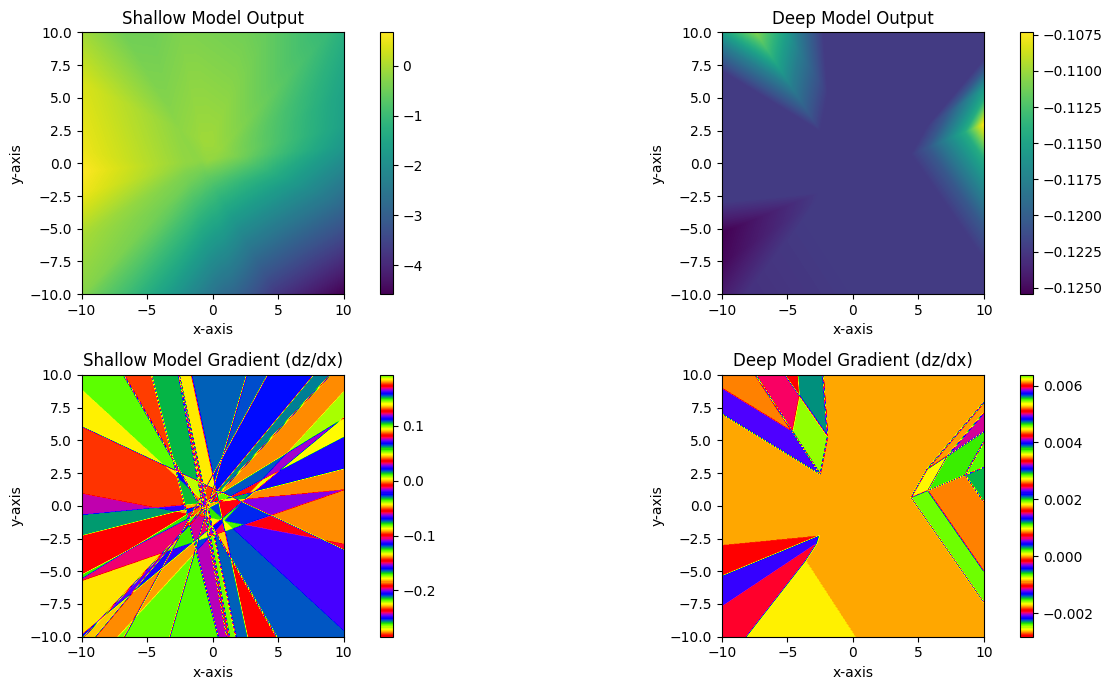

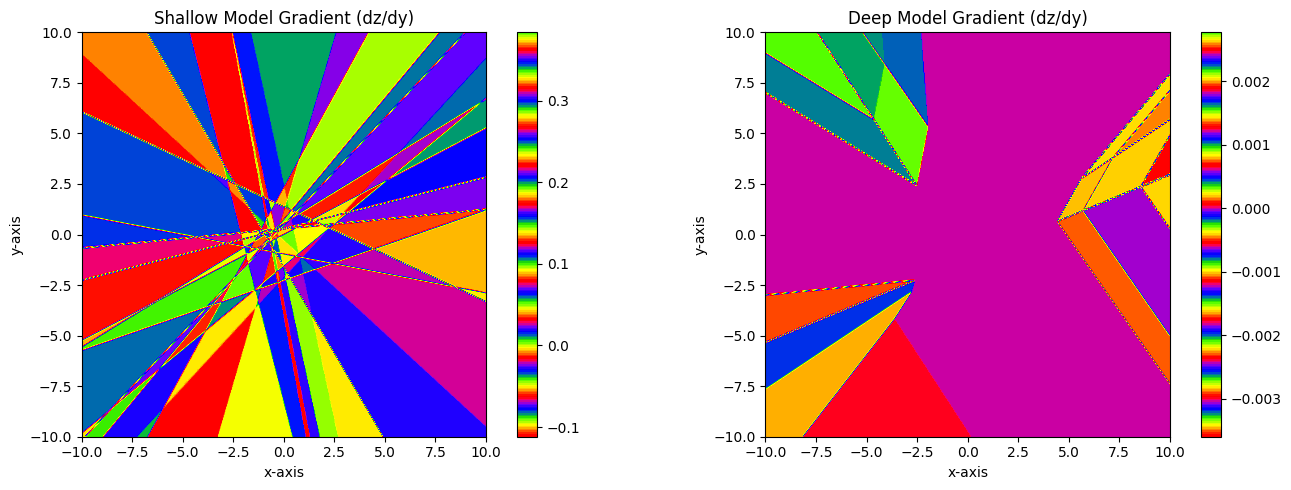

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.manual_seed(42)

with torch.no_grad():
    # Pass the grid through the shallow model and reshape the output
    output_values_shallow = shallow_model(grid_tensor).numpy().reshape(xx.shape)

    # Pass the grid through the deep model and reshape the output
    output_values_deep = deep_model(grid_tensor).numpy().reshape(xx.shape)

# Calculate Gradients Using numpy.gradient for Both Models

# Shallow model gradients
gradient_y_shallow, gradient_x_shallow = np.gradient(output_values_shallow, y_values, x_values)

# Deep model gradients
gradient_y_deep, gradient_x_deep = np.gradient(output_values_deep, y_values, x_values)


# Plot Outputs Side by Side for Comparison
plt.figure(figsize=(14, 7))

# Shallow Model Output
plt.subplot(2, 2, 1)
plt.imshow(output_values_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Shallow Model Output")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Output
plt.subplot(2, 2, 2)
plt.imshow(output_values_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Deep Model Output")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Shallow Model Gradient (dz/dx)
plt.subplot(2, 2, 3)
plt.imshow(gradient_x_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Shallow Model Gradient (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Gradient (dz/dx)
plt.subplot(2, 2, 4)
plt.imshow(gradient_x_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Deep Model Gradient (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))

# Shallow Model Gradient (dz/dy)
plt.subplot(1, 2, 1)
plt.imshow(gradient_y_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Shallow Model Gradient (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Gradient (dz/dy)
plt.subplot(1, 2, 2)
plt.imshow(gradient_y_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Deep Model Gradient (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.tight_layout()
plt.show()


Key Takeaways
- The shallow model is a simpler network that creates smoother, less complex outputs and exhibits more general but distributed sensitivity across the input space.
- The deep model, on the other hand, is capable of capturing detailed, non-linear relationships with distinct regions of high sensitivity, which results in sharper gradients and more complex outputs. This makes it better suited for capturing intricate patterns, but it also increases the risk of overfitting if not handled properly.
- The differences in the gradients (dz/dx and dz/dy) show that the deep model has more localized and targeted sensitivity, while the shallow model's sensitivity is more generalized and spread out.